In [83]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-12k-images-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-12k-images-dataset


In [84]:
import os
os.listdir(path)

['Face Mask Dataset']

In [85]:
os.listdir(path + "/Face Mask Dataset")

['Validation', 'Test', 'Train']

In [86]:
os.listdir(path+"/Face Mask Dataset/Train")

['WithoutMask', 'WithMask']

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [88]:
train_dir = path+"/Face Mask Dataset/Train"
test_dir = path+"/Face Mask Dataset/Test"
valid_dir = path+"/Face Mask Dataset/Validation"

In [89]:
training_dataset = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=0,
    width_shift_range=0.0,
    height_shift_range=0.0,
    shear_range=0.0,
    zoom_range=0.0,
    horizontal_flip=False,
    vertical_flip=False,
    rescale=1/255.0,
    #preprocessing_function=preprocess_input,
    #validation_split=0.1,
).flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical",
    #subset="validation",
    seed = 0,
    shuffle=True
)

Found 10000 images belonging to 2 classes.


In [90]:
Batch = next(training_dataset)
x_batch, y_batch = Batch

In [91]:
y_batch

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.]], dtype=float32)

In [92]:
classes = list(training_dataset.class_indices.keys())
classes

['WithMask', 'WithoutMask']

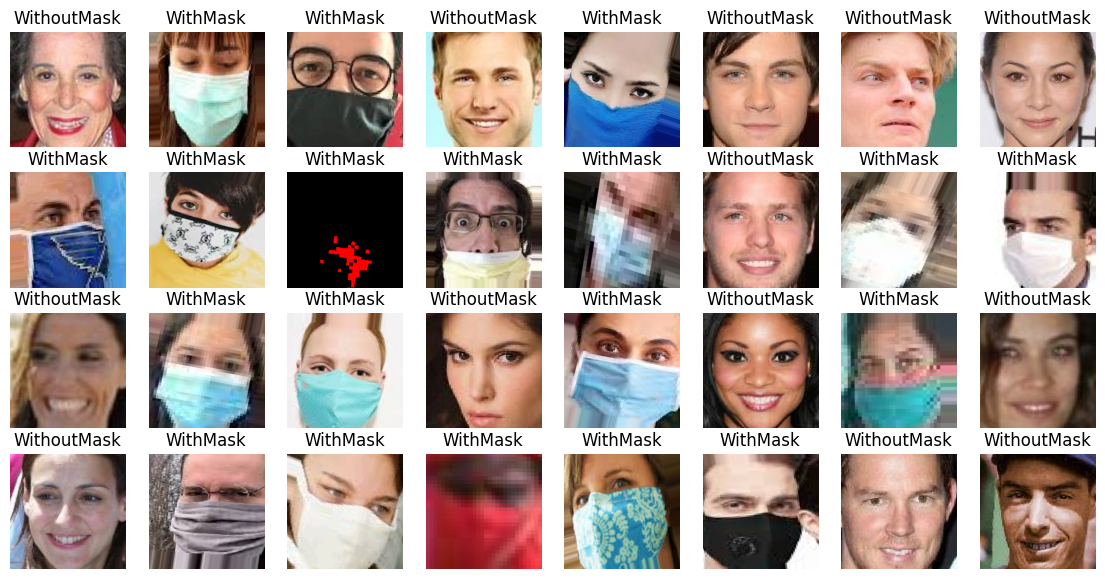

In [93]:
plt.figure(figsize=(14, 7))
for i in range (32):
  plt.subplot(4, 8 ,i+1)
  plt.imshow(x_batch[i])
  plt.title(classes[np.argmax(y_batch[i])])
  plt.axis("off")

In [94]:
testing_dataset = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
).flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical",
    seed = 0,
    shuffle=False
)

Found 992 images belonging to 2 classes.


In [95]:
validation_dataset = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
).flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical",
    seed = 0,
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [96]:
model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    include_top = False,
    weights = "imagenet",
    input_shape=(224,224,3)
)

In [97]:
model.trainable = False

In [98]:
add = tf.keras.layers.GlobalMaxPooling2D()(model.output)
add = tf.keras.layers.Dense(1024,activation="relu")(add)
add = tf.keras.layers.BatchNormalization()(add)
add = tf.keras.layers.Dropout(0.5)(add)
output = tf.keras.layers.Dense(2,activation="softmax")(add)
model = tf.keras.models.Model(model.input,output)

In [99]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,575,874 (13.64 MB)

 Trainable params: 1,315,842 (5.02 MB)

 Non-trainable params: 2,260,032 (8.62 MB)

In [100]:
model.compile(optimizer='adam',loss='categorical_crossentropy',
              metrics=['accuracy'])

In [101]:
early_stooping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)
ReduceLR = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2)

file_path = "output/best_model.keras"
modelcheckpoint = tf.keras.callbacks.ModelCheckpoint(
    file_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger(
    "training_log.csv",
    separator=",",
    append=True
)


In [102]:
history =model.fit(
    training_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=[early_stooping,ReduceLR,modelcheckpoint,csv_logger]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9699 - loss: 0.0966
Epoch 1: val_loss improved from None to 0.02138, saving model to output/best_model.keras

Epoch 1: finished saving model to output/best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 162ms/step - accuracy: 0.9806 - loss: 0.0629 - val_accuracy: 0.9912 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9901 - loss: 0.0317
Epoch 2: val_loss did not improve from 0.02138
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9800 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9899 - loss: 0.0338
Epoch 3: val_loss did not improve from 0.02138
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.9917 - loss: 0.0253 - val_accuracy: 0.9837 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0

In [103]:
loss,acc = model.evaluate(testing_dataset)
print("Model loss: ", loss)
print("Model Accuracy", acc)

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9970 - loss: 0.0148
Model loss:  0.014821325428783894
Model Accuracy 0.9969757795333862


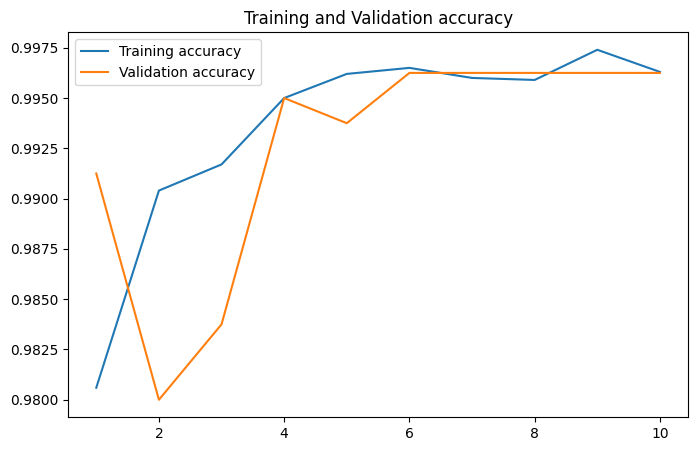

In [104]:
epochs = range(1,len(history.history["accuracy"])+1)
plt.figure(figsize=(8,5))
plt.plot(epochs,history.history["accuracy"],label="Training accuracy")
plt.plot(epochs,history.history["val_accuracy"],label="Validation accuracy")
plt.title("Training and Validation accuracy")

plt.legend()
plt.show()

In [105]:
y_pred = model.predict(testing_dataset)

31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step


In [106]:
from sklearn.metrics import confusion_matrix,classification_report

In [107]:
print(classification_report(testing_dataset.labels,y_pred.argmax(axis=-1)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       483
           1       1.00      0.99      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992

